# EDA Deep: E-CUP Matching

Известно из описания:
- `target`: 0/1 для ручной разметки, **непрерывный от 0 до 1** для LLM-разметки (мягкие метки)
- `attributes` — текст со **свернутыми JSON-атрибутами** товара
- Все товары из `items_human.parquet` ⊂ `items.parquet`; тест будет сопоставим с `items_human + matches` по объёму, товары в тестовых данных новые

План:
1. Полный проход по `items.parquet`: категории, id-диапазоны, статистики текстов
2. Разбор структуры `attributes`
3. Анализ мягких LLM-меток
4. Проверка гипотез про id1/id2

## 0. Инициализация

In [1]:
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import json, collections
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_colwidth', 200)
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
DATA = '..'

## 1. Полный проход по items.parquet

In [2]:
# Проходим по всем row group'ам, собираем агрегаты без загрузки всего файла в память
pf = pq.ParquetFile(f'{DATA}/items.parquet')
print('Row groups:', pf.num_row_groups)

cat_counts = collections.Counter()
id_min, id_max = np.inf, -np.inf
name_lens, attr_lens = [], []
batches = pf.iter_batches(batch_size=1_000_000, columns=['id', 'name', 'attributes', 'category'])
for b in batches:
    df = b.to_pandas()
    cat_counts.update(df['category'].value_counts().to_dict())
    id_min = min(id_min, df['id'].min()); id_max = max(id_max, df['id'].max())
    name_lens.append(df['name'].str.len())
    attr_lens.append(df['attributes'].str.len())
    del df

name_lens = pd.concat(name_lens); attr_lens = pd.concat(attr_lens)
print(f'Всего категорий: {len(cat_counts)}')
cats = pd.Series(dict(cat_counts)).sort_values(ascending=False)
print(cats)
print(f'\nid range: [{id_min}, {id_max}]')

Row groups: 13


Всего категорий: 20
Автотовары                 1028081
Дом и сад                   938725
Строительство и ремонт      909895
Электроника                 905213
Одежда                      827617
Красота и гигиена           745706
Галантерея и аксессуары     728338
Детские товары              703910
Спорт и отдых               666988
Канцелярские товары         659106
Хобби и творчество          646361
Мебель                      642548
Обувь                       633353
Бытовая техника             602241
Аптека                      590750
Товары для животных         558992
Продукты питания            497606
Ювелирные изделия           392755
Бытовая химия               379701
Музыкальные инструменты     339875
dtype: int64

id range: [0, 850403683810]


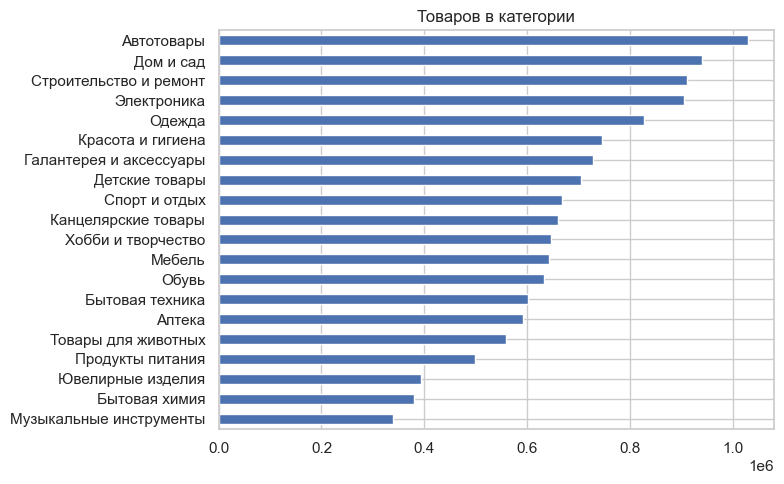

In [3]:
fig, ax = plt.subplots(figsize=(8,5))
cats.sort_values().plot.barh(ax=ax)
ax.set_title('Товаров в категории')
plt.tight_layout(); plt.show()

In [4]:
print('name len:', dict(name_lens.describe([0.5, 0.95, 0.99]).round(0)))
print('attr len:', dict(attr_lens.describe([0.5, 0.95, 0.99]).round(0)))

name len: {'count': np.float64(13397761.0), 'mean': np.float64(55.0), 'std': np.float64(31.0), 'min': np.float64(0.0), '50%': np.float64(52.0), '95%': np.float64(114.0), '99%': np.float64(155.0), 'max': np.float64(4200.0)}
attr len: {'count': np.float64(13397761.0), 'mean': np.float64(440.0), 'std': np.float64(511.0), 'min': np.float64(2.0), '50%': np.float64(366.0), '95%': np.float64(1029.0), '99%': np.float64(1660.0), 'max': np.float64(186322.0)}


## 2. Структура attributes (свернутый JSON)

In [5]:
# Смотрим сырые примеры
items_sample = next(pq.ParquetFile(f'{DATA}/items.parquet').iter_batches(batch_size=5000)).to_pandas()
for i in range(3):
    print(f'--- {items_sample.category.iloc[i]} ---')
    print(items_sample.attributes.iloc[i][:600])
    print()

--- Автотовары ---
{"бренд":"masterkit","цвет товара":"черный","страна-изготовитель":"италия","материал":"металлический сплав","количество, штук":"1","oem-номер":"77ak1494","комплектация":"в упаковке 1 шт.","партномер (артикул производителя)":"77ak1494","тип":"суппорты тормозные","вид техники":"легковые автомобили","гарантийный срок":"6 мес."}

--- Автотовары ---
{"артикул производителя":"si1117","оем номер":"si-1117; c5449lr; 4871035050; 5798114sx; fq0966; ma125; ps5682; st4871035050; tee1053; rs21008; vkds","марка автомобиля":"тойота fj крузер 4.0 2003-2018","модель автомобиля":"toyota fj cruiser 4.0 03-18","страна производства":"китай","вес с упаковкой (кг)":"1 кг","длина упаковки":"15 см","высота упаковки":"10 см","ширина упаковки":"15 см"}

--- Автотовары ---
{"бренд":"haft","oem-номер":"495001m010; 495011m010; 495913x0b0; 49591a63a5","партномер (артикул производителя)":"ga0163","тип":"шрус наружный"}



In [6]:
# Пробуем распарсить как JSON и собрать статистику ключей на сэмпле
def try_parse(s):
    try:
        return json.loads(s)
    except Exception:
        return None

parsed = items_sample['attributes'].map(try_parse)
print('Доля распарсившихся как json:', parsed.map(lambda x: x is not None).mean())

key_counter = collections.Counter()
types_counter = collections.Counter()
for obj in parsed.dropna():
    if isinstance(obj, dict):
        types_counter[type(obj).__name__] += 1
        key_counter.update(obj.keys())

print('\nТипы объектов:', dict(types_counter))
print('\nТоп-30 ключей:')
for k, v in key_counter.most_common(30):
    print(f'{k}: {v}')

Доля распарсившихся как json: 1.0

Типы объектов: {'dict': 5000}

Топ-30 ключей:
бренд: 3043
тип: 2893
партномер (артикул производителя): 2229
комплектация: 2200
высота упаковки: 1564
длина упаковки: 1563
ширина упаковки: 1563
артикул производителя: 1446
страна-изготовитель: 1285
вид техники: 1275
oem-номер: 1122
количество, штук: 1112
цвет товара: 958
материал: 898
страна производства: 739
альтернативные артикулы товара: 685
оем номер: 667
гарантийный срок: 645
марка автомобиля: 563
вес с упаковкой (кг): 563
модель автомобиля: 451
вес товара с упаковкой (г): 379
модель: 374
цвет: 354
особенности: 350
место установки: 336
название цвета: 333
количество в упаковке, шт: 307
индекс нагрузки: 272
расположение сиденья: 271


In [7]:
# Если не чистый JSON — смотрим, что мешает парсингу
bad = items_sample.loc[parsed.map(lambda x: x is None), 'attributes']
print('Не распарсилось:', len(bad))
if len(bad):
    print(bad.iloc[0][:400])

Не распарсилось: 0


In [8]:
# Значения атрибутов: какие бывают (на топ-ключе)
if key_counter:
    top_key = key_counter.most_common(1)[0][0]
    vals = [obj.get(top_key) for obj in parsed.dropna() if isinstance(obj, dict)]
    print(top_key, '→', collections.Counter(map(str, vals[:1000])).most_common(10))

бренд → [('None', 397), ('lynxauto', 29), ('stellox', 22), ('avtolider1', 20), ('kiwix', 18), ('coolpart', 17), ('febest', 14), ('patron', 13), ('sat', 13), ('autopilot', 11)]


## 3. Мягкие метки LLM

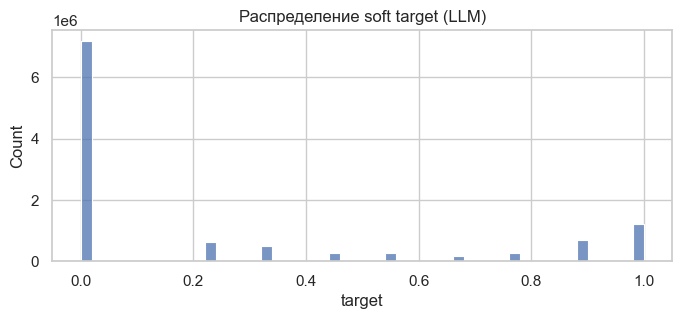

target
0.0    7184663
9.0    1223955
8.0     679881
2.0     632415
3.0     497157
7.0     276349
5.0     269160
4.0     252544
6.0     170222
1.0       1434
Name: count, dtype: int64


In [9]:
matches_llm = pd.read_parquet(f'{DATA}/matches_llm.parquet')

fig, ax = plt.subplots(figsize=(8,3))
sns.histplot(matches_llm['target'], bins=50, ax=ax)
ax.set_title('Распределение soft target (LLM)')
plt.show()

print((matches_llm['target'] * 9).round(6).value_counts().head(12))

In [10]:
# Сколько пар в разных диапазонах уверенности
t = matches_llm['target']
for lo, hi in [(0, 0), (0, 0.2), (0.2, 0.8), (0.8, 1), (1, 1)]:
    n = ((t >= lo) & (t <= hi)).sum()
    print(f'target in [{lo}, {hi}]: {n:,} ({n/len(t):.1%})')

target in [0, 0]: 7,184,663 (64.2%)
target in [0, 0.2]: 7,186,097 (64.2%)
target in [0.2, 0.8]: 2,097,847 (18.8%)
target in [0.8, 1]: 1,903,836 (17.0%)
target in [1, 1]: 1,223,955 (10.9%)


In [11]:
# Категории в LLM-парах: нужен джойн с полным items — но он большой.
# Вместо этого посмотрим распределение id: из каких диапазонов берутся id1/id2 в обоих источниках
matches_h = pd.read_parquet(f'{DATA}/matches.parquet')
for src, m in [('human', matches_h), ('llm', matches_llm.sample(1_000_000, random_state=RANDOM_STATE))]:
    print(f'--- {src} ---')
    print('id1 quantiles:', np.percentile(m.id1, [0, 25, 50, 75, 100]).round(0))
    print('id2 quantiles:', np.percentile(m.id2, [0, 25, 50, 75, 100]).round(0))

--- human ---
id1 quantiles: [3.20000000e+01 2.14748371e+11 4.29496754e+11 6.44245114e+11
 8.50403684e+11]
id2 quantiles: [1.30000000e+01 2.06158576e+11 4.29496763e+11 6.44245126e+11
 8.50403684e+11]
--- llm ---
id1 quantiles: [0.00000000e+00 2.06158592e+11 4.29496761e+11 6.44245126e+11
 8.50403684e+11]
id2 quantiles: [3.00000000e+00 2.06158579e+11 4.29496753e+11 6.44245113e+11
 8.50403684e+11]


In [12]:
# Гипотеза: id1 всегда маленький (эталонный?), id2 большой (кандидат?)
m = matches_h
print('id1 < 1e6:', (m.id1 < 1e6).mean(), '| id2 < 1e6:', (m.id2 < 1e6).mean())
print('id1 > id2 доля:', (m.id1 > m.id2).mean())

id1 < 1e6: 0.010422421195994028 | id2 < 1e6: 0.010589245570949587
id1 > id2 доля: 0.5002871567109891


## 4. items_human vs items: проверка включения

In [13]:
items_human = pd.read_parquet(f'{DATA}/items_human.parquet')
ih_ids = set(items_human['id'])
print('Товаров в human:', len(ih_ids))
# Проверяем подмножество через проход по items.parquet
found = 0
pf = pq.ParquetFile(f'{DATA}/items.parquet')
for b in pf.iter_batches(batch_size=1_000_000, columns=['id']):
    found += ih_ids.intersection(b.to_pandas()['id'].tolist()).__len__()
print('Найдено совпадений id (ожидаем len(ih_ids)):', found)

Товаров в human: 711304


Найдено совпадений id (ожидаем len(ih_ids)): 711304


In [14]:
# Категории в human-данных
print(items_human['category'].value_counts())

category
Одежда                     45878
Автотовары                 37752
Строительство и ремонт     36088
Обувь                      35936
Товары для животных        35663
Аптека                     35620
Продукты питания           35564
Мебель                     35505
Галантерея и аксессуары    35434
Спорт и отдых              35084
Хобби и творчество         35023
Дом и сад                  34923
Бытовая техника            34887
Детские товары             34791
Ювелирные изделия          34759
Электроника                34455
Канцелярские товары        34436
Красота и гигиена          34299
Бытовая химия              33284
Музыкальные инструменты    31923
Name: count, dtype: int64


## Выводы (заполнить после прогона)
- Распределение категорий в полном items
- Структура и полезность attributes
- Как использовать soft-метки LLM (веса / бинаризация / регрессия)
- Семантика id1/id2